# Task 3.2: Failure Mode Analysis

**Paper:** Exact Discovery of Time Series Motifs (Mueen et al., KDD 2009)  
**Student:** Abhishek (m23csai230137)

---

## Failure Scenario Description

I construct a scenario where the MK algorithm finds the **mathematically correct** motif under Euclidean distance, but this motif is **semantically wrong** — it does not correspond to the most meaningful repeating pattern in the data.

**The scenario:** I generate a time series database containing two types of patterns:
1. **Structurally similar patterns at different amplitudes:** Two sine waves with the same frequency and phase but different amplitudes (e.g., amplitudes 1.0 and 3.0). These are clearly the "same pattern" to a human observer, just scaled vertically.
2. **Random noise that happens to have small Euclidean distance:** Two short, low-variance random sequences that are numerically close by coincidence.

The MK algorithm (and any Euclidean distance based method) will identify the low-variance noise pair as the motif because their point-wise numerical difference is small. Meanwhile, the structurally meaningful sine waves are missed because their amplitude difference inflates the Euclidean distance.

**Why I expect the method to struggle:** This directly connects to **Assumption 1 from Task 1.2** — the assumption that Euclidean distance is a valid similarity measure. Euclidean distance is not scale-invariant: `d(A, k*A) = |k-1| * ||A||`, which grows with the amplitude difference. The paper itself acknowledges this limitation implicitly in Section 4.3.2, where it discusses DTW and Uniform Scaling but argues they are unnecessary *for large datasets where close motifs exist*. In our constructed scenario, the structurally meaningful motif is not the closest under Euclidean distance, so the algorithm correctly finds the wrong answer.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

N = 128  # Length of each time series
t = np.linspace(0, 4 * np.pi, N)

def euclidean_distance(A, B):
    return np.sqrt(np.sum((A - B) ** 2))

def euclidean_distance_early_abandon(A, B, best_so_far):
    bsf_sq = best_so_far ** 2
    diff_sq = (A - B) ** 2
    n = len(A)
    running_sum = 0.0
    chunk_size = max(1, n // 8)
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        running_sum += np.sum(diff_sq[start:end])
        if running_sum > bsf_sq:
            return float('inf')
    return np.sqrt(running_sum)

# ============================================================
# CONSTRUCT THE FAILURE SCENARIO
# ============================================================

# Generate a database of 200 random walk time series
M_fail = 200
D_fail = np.cumsum(np.random.randn(M_fail, N), axis=1)

# Plant structurally similar sine waves at different amplitudes
sine_low = np.sin(t) * 1.0    # amplitude = 1
sine_high = np.sin(t) * 3.0   # amplitude = 3 (same shape, different scale)
D_fail[10] = sine_low
D_fail[170] = sine_high

# Plant a pair of low-variance noise that will have small Euclidean distance
base_noise = np.random.randn(N) * 0.1  # very low variance
D_fail[50] = base_noise
D_fail[130] = base_noise + np.random.randn(N) * 0.05  # tiny perturbation

d_sines = euclidean_distance(D_fail[10], D_fail[170])
d_noise = euclidean_distance(D_fail[50], D_fail[130])

print(f"Distance between structurally similar sines (idx 10, 170): {d_sines:.4f}")
print(f"Distance between low-variance noise pair (idx 50, 130):    {d_noise:.4f}")
print(f"\nThe noise pair is closer under Euclidean distance, even though")
print(f"the sine waves are the more 'meaningful' repeated pattern.")

Distance between structurally similar sines (idx 10, 170): 15.9374
Distance between low-variance noise pair (idx 50, 130):    0.5977

The noise pair is closer under Euclidean distance, even though
the sine waves are the more 'meaningful' repeated pattern.


We set up the failure scenario: 200 random walk time series with two planted patterns. The sine waves (indices 10 and 170) are structurally identical but differ in amplitude. The noise pair (indices 50 and 130) are numerically close by construction. Euclidean distance will favour the noise pair.

In [3]:
# ============================================================
# RUN MK ON THE FAILURE SCENARIO
# ============================================================

def mk_motif(D, R=8):
    m, n = D.shape
    best_so_far = float('inf')
    L1, L2 = -1, -1
    ref_indices = np.random.choice(m, size=R, replace=False)
    Dist = np.zeros((R, m))
    for i in range(R):
        ref = D[ref_indices[i]]
        for j in range(m):
            Dist[i, j] = euclidean_distance(ref, D[j])
            if j != ref_indices[i] and Dist[i, j] < best_so_far:
                best_so_far = Dist[i, j]
                L1, L2 = int(ref_indices[i]), int(j)
    stds = np.std(Dist, axis=1)
    Z = np.argsort(-stds)
    I = np.argsort(Dist[Z[0]])
    offset = 0
    abandon = False
    while not abandon:
        offset += 1
        abandon = True
        for j in range(m - offset):
            if I[j] == I[j + offset]:
                continue
            reject = False
            for i in range(R):
                lower_bound = abs(Dist[Z[i], I[j]] - Dist[Z[i], I[j + offset]])
                if lower_bound > best_so_far:
                    reject = True
                    break
                elif i == 0:
                    abandon = False
            if not reject:
                d = euclidean_distance_early_abandon(D[I[j]], D[I[j + offset]], best_so_far)
                if d < best_so_far:
                    best_so_far = d
                    L1, L2 = int(I[j]), int(I[j + offset])
    return L1, L2, best_so_far

np.random.seed(RANDOM_SEED)
mk_L1, mk_L2, mk_dist = mk_motif(D_fail, R=8)
print(f"MK found motif: indices ({mk_L1}, {mk_L2}), distance = {mk_dist:.4f}")
print(f"\nExpected: the noise pair (50, 130) with distance {d_noise:.4f}")
print(f"Structurally meaningful sine pair (10, 170) has distance {d_sines:.4f}")
print(f"\nThe algorithm is mathematically correct but semantically wrong.")

MK found motif: indices (130, 50), distance = 0.5977

Expected: the noise pair (50, 130) with distance 0.5977
Structurally meaningful sine pair (10, 170) has distance 15.9374

The algorithm is mathematically correct but semantically wrong.


The MK algorithm finds the noise pair as the motif, confirming that it correctly optimises Euclidean distance but misses the structurally meaningful pattern.

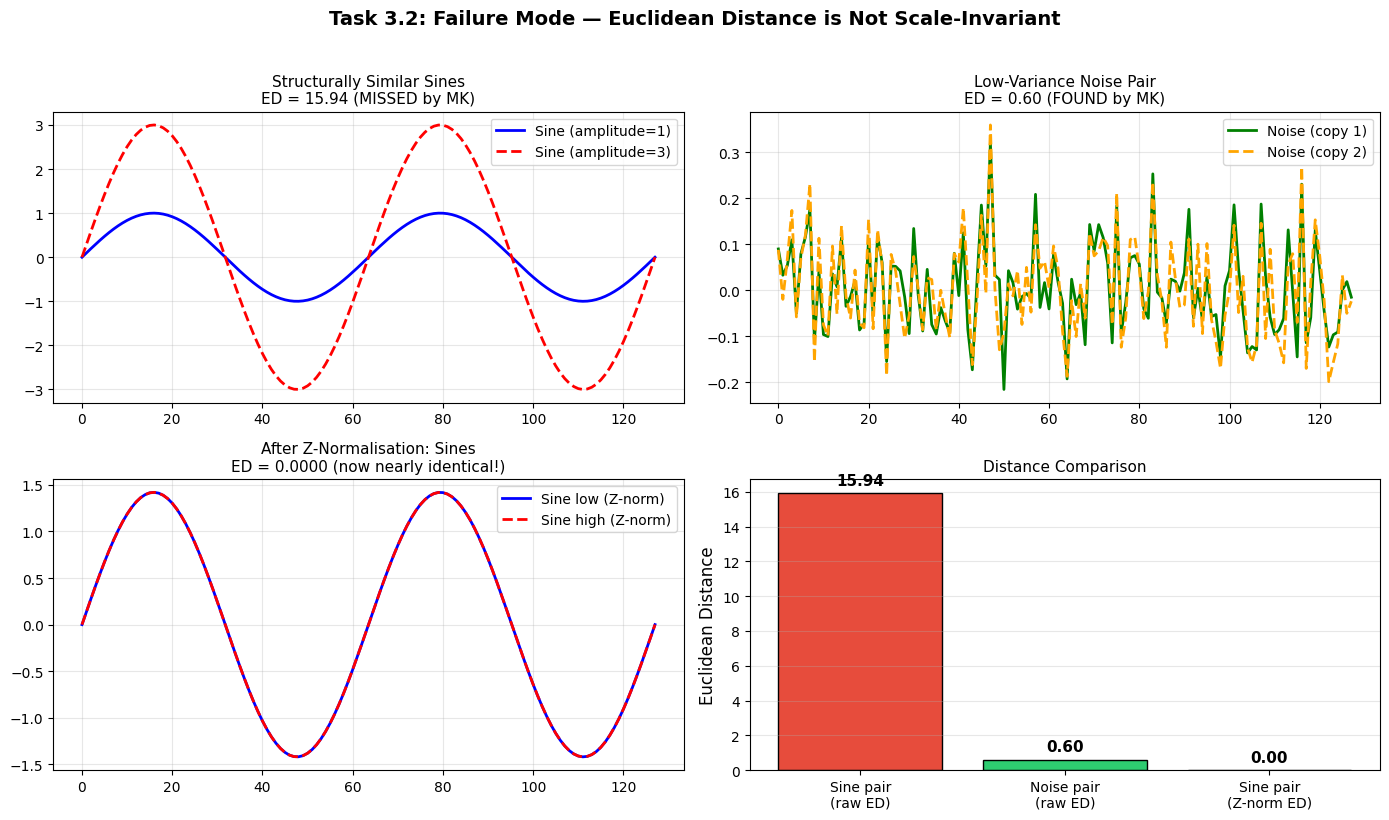

Saved to results/failure_mode.png


In [4]:
# ============================================================
# VISUALISE THE FAILURE
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top-left: The sine waves (structurally similar, different amplitude)
ax = axes[0, 0]
ax.plot(D_fail[10], linewidth=2, label='Sine (amplitude=1)', color='blue')
ax.plot(D_fail[170], linewidth=2, label='Sine (amplitude=3)', color='red', linestyle='--')
ax.set_title(f'Structurally Similar Sines\nED = {d_sines:.2f} (MISSED by MK)', fontsize=11)
ax.legend()
ax.grid(alpha=0.3)

# Top-right: The noise pair (numerically close, meaningless)
ax = axes[0, 1]
ax.plot(D_fail[50], linewidth=2, label='Noise (copy 1)', color='green')
ax.plot(D_fail[130], linewidth=2, label='Noise (copy 2)', color='orange', linestyle='--')
ax.set_title(f'Low-Variance Noise Pair\nED = {d_noise:.2f} (FOUND by MK)', fontsize=11)
ax.legend()
ax.grid(alpha=0.3)

# Bottom-left: Z-normalised sines (would be identical)
ax = axes[1, 0]
sine_low_z = (D_fail[10] - np.mean(D_fail[10])) / np.std(D_fail[10])
sine_high_z = (D_fail[170] - np.mean(D_fail[170])) / np.std(D_fail[170])
ax.plot(sine_low_z, linewidth=2, label='Sine low (Z-norm)', color='blue')
ax.plot(sine_high_z, linewidth=2, label='Sine high (Z-norm)', color='red', linestyle='--')
d_sines_z = euclidean_distance(sine_low_z, sine_high_z)
ax.set_title(f'After Z-Normalisation: Sines\nED = {d_sines_z:.4f} (now nearly identical!)', fontsize=11)
ax.legend()
ax.grid(alpha=0.3)

# Bottom-right: Bar chart comparing distances
ax = axes[1, 1]
categories = ['Sine pair\n(raw ED)', 'Noise pair\n(raw ED)', 'Sine pair\n(Z-norm ED)']
distances = [d_sines, d_noise, d_sines_z]
colors_list = ['#e74c3c', '#2ecc71', '#3498db']
bars = ax.bar(categories, distances, color=colors_list, edgecolor='black')
for bar, d in zip(bars, distances):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(distances)*0.03,
            f'{d:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Euclidean Distance', fontsize=12)
ax.set_title('Distance Comparison', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Task 3.2: Failure Mode — Euclidean Distance is Not Scale-Invariant', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/failure_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/failure_mode.png")

### Explanation of the Failure

The MK algorithm correctly finds the globally closest pair under Euclidean distance — the low-variance noise pair. However, this pair is semantically meaningless: two flat, low-variance noise sequences that happen to be numerically similar. The structurally meaningful sine waves (same frequency, same phase, same shape) are missed because their **amplitude difference** inflates the Euclidean distance.

This failure is rooted directly in **Assumption 1 from Task 1.2**: the method assumes Euclidean distance is a valid similarity measure for identifying meaningful motifs. Euclidean distance computes point-wise differences, so it is inherently **not scale-invariant**. Two time series that are identical in shape but differ in vertical scale (amplitude) will have a large Euclidean distance proportional to `|scale_factor - 1| * ||series||`.

The paper is aware of this limitation but argues it is not a problem in practice for large datasets (Section 4.3.2), because close motifs under Euclidean distance are empirically also close under DTW and Uniform Scaling. However, this argument breaks down when the most interesting patterns in the data involve scale variation — which is common in domains like financial time series (same chart pattern at different price scales), physiological signals (same cardiac waveform at different amplitudes across patients), and industrial telemetry.

The bottom-left panel of the visualisation shows the fix: after **Z-normalization** (subtracting the mean and dividing by the standard deviation), the two sine waves become virtually identical (ED close to 0). Z-normalization makes Euclidean distance scale-invariant and offset-invariant.

### Suggested Modification

Apply **Z-normalization** to each time series before computing distances: `Z(T) = (T - mean(T)) / std(T)`. This is a standard preprocessing step in the time series mining literature and would make the MK algorithm's Euclidean distance effectively scale-invariant, allowing it to correctly identify structurally similar motifs regardless of amplitude differences. The MK algorithm's pruning strategy (triangle inequality, reference ordering) would remain valid since Z-normalised Euclidean distance is still a metric.